[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/02b_neural_network_digit_recognition.ipynb)
[![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/brianjalaian/CAP6606_ML_ISR/blob/main/notebooks/02b_neural_network_digit_recognition.ipynb)

# Applied Neural Networks: Handwritten Digit Recognition

**From benchmark accuracy to deployment evidence**

We classify $8\times8$ grayscale images from scikit-learn's built-in Digits dataset. Because the data ships with scikit-learn, the entire case study is reproducible offline.

## Learning Objectives

1. Build a leakage-safe image-classification split
2. Compare a linear baseline with a multilayer perceptron
3. Interpret a confusion matrix and inspect high-confidence errors
4. Stress-test robustness under increasing pixel noise
5. Build a confidence-based abstention policy
6. Quantify parameter count and inference latency

## 1. Load and Inspect the Dataset

Each example is an $8\times8$ image with integer pixel intensity from 0 to 16. The label is one of ten digits. Flattened inputs have shape $(B,64)$; the MLP output has shape $(B,10)$.

In [1]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier

warnings.filterwarnings("ignore", category=ConvergenceWarning)
np.set_printoptions(precision=3, suppress=True)
plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

digits = load_digits()
X_images = digits.images
X = digits.data.astype(np.float64) / 16.0
y = digits.target
print(f"Images: {X_images.shape}; flattened features: {X.shape}; classes: {np.unique(y)}")
print(f"Pixel range after scaling: [{X.min():.1f}, {X.max():.1f}]")

Images: (1797, 8, 8); flattened features: (1797, 64); classes: [0 1 2 3 4 5 6 7 8 9]
Pixel range after scaling: [0.0, 1.0]


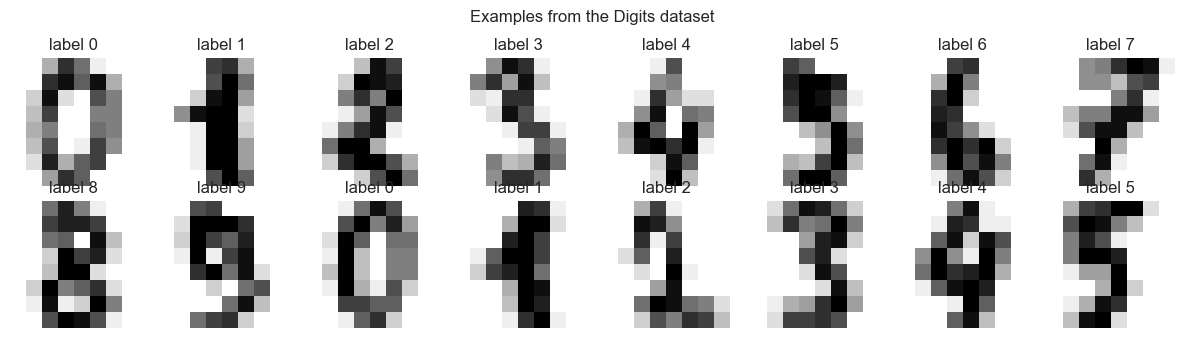

In [2]:
fig, axes = plt.subplots(2, 8, figsize=(12, 3.4))
for ax, image, label in zip(axes.ravel(), X_images[:16], y[:16]):
    ax.imshow(image, cmap="gray_r", vmin=0, vmax=16)
    ax.set_title(f"label {label}")
    ax.axis("off")
plt.suptitle("Examples from the Digits dataset")
plt.tight_layout()
plt.show()

## 2. Split Before Modeling

We create train, validation, and test sets with stratification. The test set remains untouched until final evaluation. Pixel scaling uses the known physical range $[0,16]$, so no statistics are learned from held-out examples.

In [3]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, stratify=y_train_full, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}; validation: {X_val.shape}; test: {X_test.shape}")
print("Class counts in train:", np.bincount(y_train))

Train: (1149, 64); validation: (288, 64); test: (360, 64)
Class counts in train: [113 117 114 117 116 116 116 114 111 115]


## 3. Establish a Linear Baseline

Multinomial logistic regression gives a strong, interpretable baseline. It can only create linear class boundaries in the 64-dimensional pixel space.

In [4]:
baseline = LogisticRegression(C=2.0, max_iter=2500, random_state=RANDOM_STATE)
baseline.fit(X_train, y_train)
baseline_val_prob = baseline.predict_proba(X_val)
print(f"Baseline validation accuracy: {baseline.score(X_val, y_val):.3f}")
print(f"Baseline validation log-loss: {log_loss(y_val, baseline_val_prob):.3f}")

Baseline validation accuracy: 0.979
Baseline validation log-loss: 0.123


## 4. Train a Multilayer Perceptron

Architecture: $64\rightarrow128\rightarrow64\rightarrow10$ with ReLU hidden activations. Adam performs mini-batch updates, $L_2$ regularization controls weight magnitude, and internal early stopping restores the best validation state found during training.

In [5]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation="relu", solver="adam",
    batch_size=64, learning_rate_init=1e-3, alpha=1e-4,
    max_iter=200, early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=20, random_state=RANDOM_STATE,
)
mlp.fit(X_train, y_train)

mlp_val_prob = mlp.predict_proba(X_val)
print(f"MLP stopped after {mlp.n_iter_} epochs")
print(f"MLP validation accuracy: {mlp.score(X_val, y_val):.3f}")
print(f"MLP validation log-loss: {log_loss(y_val, mlp_val_prob):.3f}")

MLP stopped after 81 epochs
MLP validation accuracy: 0.976
MLP validation log-loss: 0.072


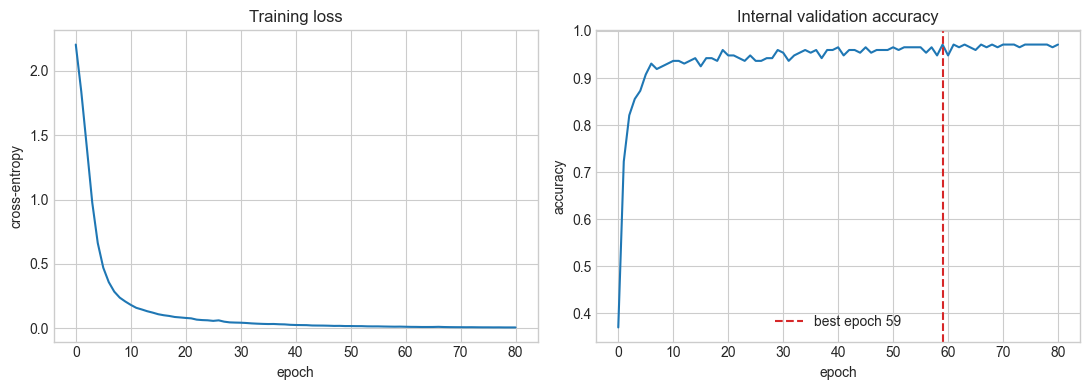

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(mlp.loss_curve_)
axes[0].set(title="Training loss", xlabel="epoch", ylabel="cross-entropy")
if mlp.validation_scores_ is not None:
    axes[1].plot(mlp.validation_scores_)
    best_epoch = int(np.argmax(mlp.validation_scores_))
    axes[1].axvline(best_epoch, color="tab:red", linestyle="--", label=f"best epoch {best_epoch}")
    axes[1].legend()
axes[1].set(title="Internal validation accuracy", xlabel="epoch", ylabel="accuracy")
plt.tight_layout()
plt.show()

## 5. Final Test Evaluation

Model selection used the validation set. We now evaluate the chosen models once on the held-out test set.

In [7]:
models = {"Linear baseline": baseline, "MLP": mlp}
for name, model in models.items():
    probabilities = model.predict_proba(X_test)
    predictions = probabilities.argmax(axis=1)
    print(f"{name:15s} accuracy={accuracy_score(y_test, predictions):.3f}, log-loss={log_loss(y_test, probabilities):.3f}")

y_pred = mlp.predict(X_test)
print("\nMLP classification report:\n")
print(classification_report(y_test, y_pred, digits=3))

Linear baseline accuracy=0.964, log-loss=0.139
MLP             accuracy=0.967, log-loss=0.090

MLP classification report:

              precision    recall  f1-score   support

           0      1.000     0.944     0.971        36
           1      0.868     0.917     0.892        36
           2      0.971     0.971     0.971        35
           3      1.000     1.000     1.000        37
           4      0.973     1.000     0.986        36
           5      1.000     1.000     1.000        37
           6      1.000     0.972     0.986        36
           7      0.973     1.000     0.986        36
           8      0.886     0.886     0.886        35
           9      1.000     0.972     0.986        36

    accuracy                          0.967       360
   macro avg      0.967     0.966     0.966       360
weighted avg      0.968     0.967     0.967       360



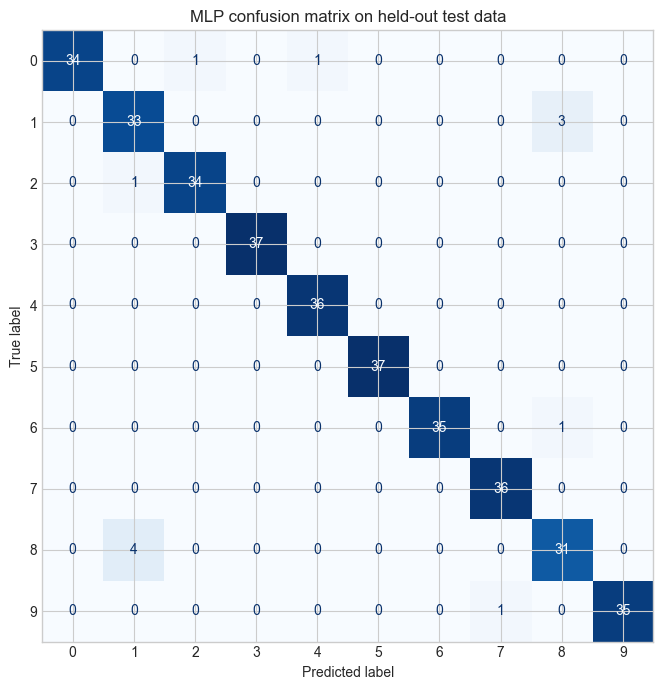

In [8]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", colorbar=False, ax=ax)
ax.set_title("MLP confusion matrix on held-out test data")
plt.tight_layout()
plt.show()

## 6. Inspect the Mistakes

Aggregate metrics do not show *how* a model fails. We sort incorrect predictions by confidence to find the errors the model is most certain about—often the most important cases to audit.

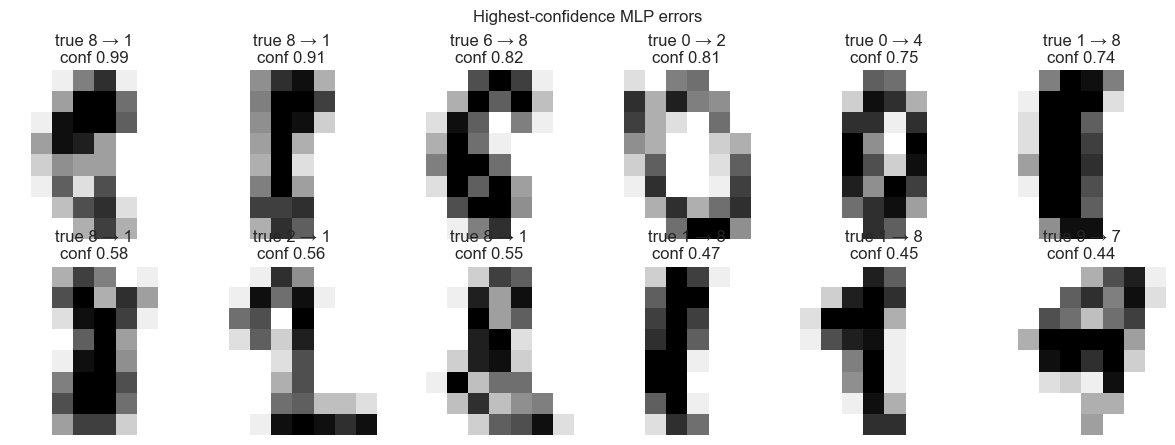

Incorrect test examples: 12 of 360


In [9]:
test_prob = mlp.predict_proba(X_test)
test_pred = test_prob.argmax(axis=1)
confidence = test_prob.max(axis=1)
wrong = np.flatnonzero(test_pred != y_test)
wrong = wrong[np.argsort(confidence[wrong])[::-1]]

n_show = min(12, len(wrong))
fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))
for ax in axes.ravel():
    ax.axis("off")
for ax, idx in zip(axes.ravel(), wrong[:n_show]):
    ax.imshow(X_test[idx].reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
    ax.set_title(f"true {y_test[idx]} → {test_pred[idx]}\nconf {confidence[idx]:.2f}")
    ax.axis("off")
plt.suptitle("Highest-confidence MLP errors")
plt.tight_layout()
plt.show()
print(f"Incorrect test examples: {len(wrong)} of {len(y_test)}")

## 7. Robustness Stress Test: Pixel Noise

Clean test accuracy is not a robustness guarantee. We add Gaussian noise of increasing standard deviation to the scaled pixels and clip back to $[0,1]$. This is not a complete deployment test, but it reveals sensitivity to a plausible input corruption.

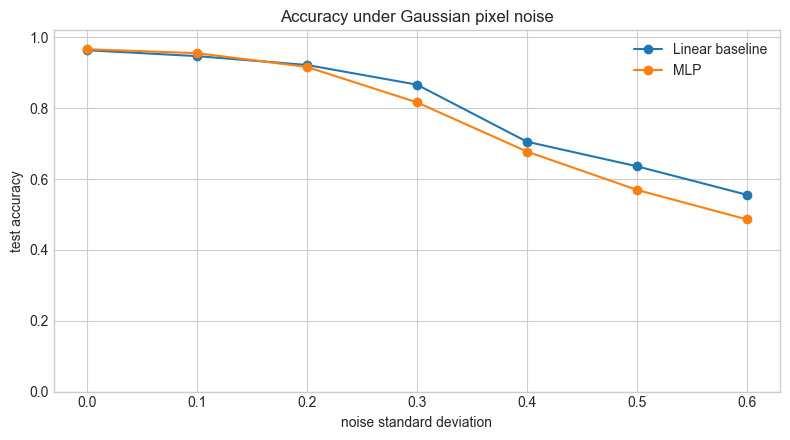

Linear baseline: clean=0.964, σ=0.3 → 0.867, σ=0.6 → 0.556
MLP            : clean=0.967, σ=0.3 → 0.817, σ=0.6 → 0.486


In [10]:
noise_rng = np.random.default_rng(RANDOM_STATE)
noise_levels = np.linspace(0, 0.6, 7)
robustness = {name: [] for name in models}

for sigma in noise_levels:
    noisy = np.clip(X_test + noise_rng.normal(0, sigma, size=X_test.shape), 0, 1)
    for name, model in models.items():
        robustness[name].append(model.score(noisy, y_test))

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, scores in robustness.items():
    ax.plot(noise_levels, scores, marker="o", label=name)
ax.set(title="Accuracy under Gaussian pixel noise", xlabel="noise standard deviation", ylabel="test accuracy", ylim=(0, 1.02))
ax.legend()
plt.tight_layout()
plt.show()

for name, scores in robustness.items():
    print(f"{name:15s}: clean={scores[0]:.3f}, σ=0.3 → {scores[3]:.3f}, σ=0.6 → {scores[-1]:.3f}")

## 8. Confidence-Based Abstention

In a safety-sensitive system, the classifier can defer uncertain examples to a human or a slower specialist model. Raising the confidence threshold typically increases accuracy on accepted examples while reducing coverage.

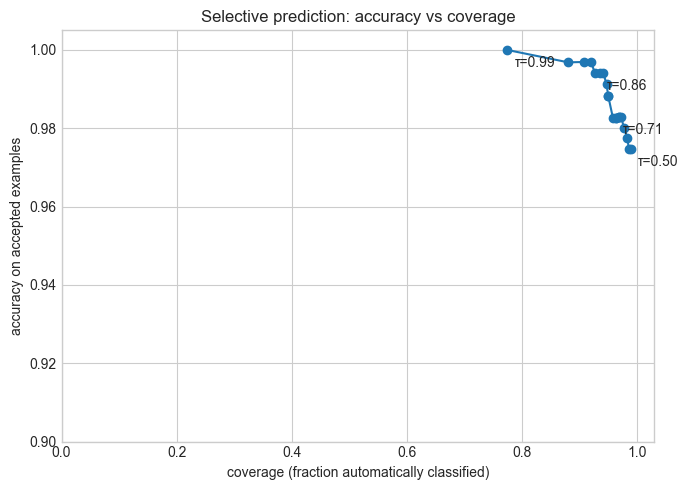

threshold=0.50: coverage=0.989, accepted accuracy=0.975
threshold=0.80: coverage=0.950, accepted accuracy=0.988
threshold=0.95: coverage=0.894, accepted accuracy=0.997


In [11]:
thresholds = np.linspace(0.50, 0.99, 20)
coverage, selective_accuracy = [], []
for threshold in thresholds:
    accepted = confidence >= threshold
    coverage.append(accepted.mean())
    selective_accuracy.append(accuracy_score(y_test[accepted], test_pred[accepted]) if accepted.any() else np.nan)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(coverage, selective_accuracy, marker="o")
for i in (0, 8, 14, 19):
    ax.annotate(f"τ={thresholds[i]:.2f}", (coverage[i], selective_accuracy[i]), xytext=(5, -12), textcoords="offset points")
ax.set(title="Selective prediction: accuracy vs coverage", xlabel="coverage (fraction automatically classified)", ylabel="accuracy on accepted examples", xlim=(0, 1.03), ylim=(0.9, 1.005))
plt.tight_layout()
plt.show()

for threshold in (0.50, 0.80, 0.95):
    accepted = confidence >= threshold
    print(f"threshold={threshold:.2f}: coverage={accepted.mean():.3f}, accepted accuracy={accuracy_score(y_test[accepted], test_pred[accepted]):.3f}")

Confidence is not automatically calibrated. A production abstention threshold should be selected on a validation set using domain costs, then monitored after deployment.

## 9. Model Size and Inference Latency

Accuracy is only one deployment constraint. Parameter count approximates memory needs; batch inference timing provides a rough local latency comparison. These timings are machine-specific, so interpret the ratio more than the absolute numbers.

In [12]:
def parameter_count(model):
    if isinstance(model, MLPClassifier):
        return sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_)
    return model.coef_.size + model.intercept_.size

def median_batch_latency_ms(model, X_batch, repeats=250):
    timings = []
    for _ in range(repeats):
        start = time.perf_counter()
        model.predict_proba(X_batch)
        timings.append((time.perf_counter() - start) * 1000)
    return float(np.median(timings))

batch = X_test[:128]
for name, model in models.items():
    print(f"{name:15s}: {parameter_count(model):>7,d} parameters, median 128-image latency={median_batch_latency_ms(model, batch):.3f} ms")

Linear baseline:     650 parameters, median 128-image latency=0.047 ms
MLP            :  17,226 parameters, median 128-image latency=0.091 ms


## 10. Deployment Card

| Question | Evidence from this notebook | Remaining gap |
|---|---|---|
| Does it classify clean held-out digits? | accuracy, log-loss, per-class report | external dataset |
| Which mistakes occur? | confusion matrix, confident-error gallery | domain expert review |
| Does corruption hurt? | controlled Gaussian-noise curve | real sensor artifacts |
| Can it defer uncertain cases? | accuracy–coverage curve | calibration and cost study |
| Can it run cheaply? | parameters and local batch latency | target-hardware benchmark |

The evidence supports a classroom prototype—not an unrestricted production claim.

## Summary

- The MLP improves on a linear baseline by learning nonlinear pixel interactions.
- Test accuracy must be paired with log-loss, per-class results, and concrete error inspection.
- Robustness degrades as input noise rises; clean performance does not certify shifted inputs.
- Confidence-based abstention exposes an explicit accuracy–coverage trade-off.
- Architecture choice affects both capacity and deployment cost.

## Exercises

1. Tune hidden width and $L_2$ strength using only the validation set, then evaluate once on test.
2. Replace Gaussian noise with random pixel dropout or small translations.
3. Compute an expected cost curve for automatic prediction versus human review.
4. Calibrate probabilities with a validation set and compare the accuracy–coverage curve.
5. Implement the same MLP in PyTorch and verify that the tensor shapes match the lecture notation.

## References

- Dua, D., & Graff, C. (2019). *UCI Machine Learning Repository: Optical Recognition of Handwritten Digits*. https://archive.ics.uci.edu/dataset/80/optical+recognition+of+handwritten+digits
- Pedregosa, F. et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830. https://jmlr.org/papers/v12/pedregosa11a.html
- Geifman, Y., & El-Yaniv, R. (2017). *Selective Classification for Deep Neural Networks*. NeurIPS. https://proceedings.neurips.cc/paper/2017/hash/4a8423d5e91fda00bb7e46540e2b0cf1-Abstract.html
- Raschka, S., & Mirjalili, V. (2022). *Machine Learning with PyTorch and Scikit-Learn*, Chapters 11–12.